# Model vs. competitors — TAUSO ASO-efficacy benchmark

Compares the single TAUSO model against the competitor scorers (OligoAI, PFRED, OligoWalk,
sfold, miRanda) on the **held-out test split**.

**How to remake these graphs** (new data / feature / architecture):
1. retrain — `python -m notebooks.models.train_model`
2. re-evaluate — `python -m notebooks.models.Evaluation.evaluate`
3. restart-and-run-all this notebook.

Everything below reads only the tidy result files written by `evaluate.py`
(`metrics_summary.csv`, `per_group_spearman.csv`, `test_predictions.parquet`). To add a new
model, give it a prediction column in `test_predictions.parquet` (or list it in `evaluate.py`'s
scorers) and re-run — every figure picks it up automatically.

In [1]:
# --- CONFIG: the only cell you normally edit ---------------------------------
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path("../../models/Evaluation/results")   # output of evaluate.py

HIGHLIGHT = "TAUSO"            # our model — drawn in the accent colour
# representative column per competitor tool for the headline figures
HEADLINE_SCORERS = ["TAUSO", "oligo_ai_score", "PFRED_PLS", "OW_Overall",
                    "sfold_accessibility", "miranda_score"]
DISPLAY = {
    "TAUSO": "TAUSO (ours)", "oligo_ai_score": "OligoAI",
    "PFRED_PLS": "PFRED", "PFRED_SVM": "PFRED (SVM)",
    "OW_Overall": "OligoWalk", "OW_Tm": "OligoWalk (Tm)",
    "OW_Intra_Oligo": "OligoWalk (intra)", "OW_Duplex": "OligoWalk (duplex)",
    "sfold_accessibility": "sfold", "miranda_score": "miRanda",
    "miranda_energy": "miRanda (energy)",
}
ACCENT, OTHER = "#c0392b", "#5b8db8"
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

def disp(s):    return DISPLAY.get(s, s)
def colors(scorers): return [ACCENT if s == HIGHLIGHT else OTHER for s in scorers]

In [2]:
# --- load the tidy results ---------------------------------------------------
summary  = pd.read_csv(RESULTS / "metrics_summary.csv")
pergroup = pd.read_csv(RESULTS / "per_group_spearman.csv")
preds    = pd.read_parquet(RESULTS / "test_predictions.parquet")
print("test oligos:", len(preds), "| scorers:", summary.scorer.nunique(),
      "| groupings:", [g for g in summary.grouping.unique() if g != "GLOBAL"])
summary.head()

test oligos: 20846 | scorers: 11 | groupings: ['patent_id', 'gene x cell_line', 'custom_id']


,scorer,grouping,n_cohorts,spearman_median,spearman_mean,top5_inhib_median,top5_inhib_mean,top10_inhib_median,top10_inhib_mean,ndcg5_median,ndcg5_mean,ndcg10_median,ndcg10_mean,p@5_median,p@5_mean,p@10_median,p@10_mean,global_spearman,MAE,RMSE
0,TAUSO,patent_id,23,0.471943,0.442269,78.2,74.704348,75.8,72.247826,0.860129,0.817900,0.868360,0.820516,0.2,0.226087,0.3,0.308696,NaN,NaN,NaN
1,TAUSO,gene x cell_line,25,0.447542,0.439827,77.8,74.400000,75.7,72.368000,0.841847,0.815621,0.848055,0.819038,0.2,0.216000,0.3,0.296000,NaN,NaN,NaN
2,TAUSO,custom_id,245,0.493571,0.482983,68.4,66.573061,65.2,63.531020,0.799631,0.777838,0.804088,0.781933,0.2,0.283607,0.4,0.386364,NaN,NaN,NaN
3,oligo_ai_score,patent_id,23,0.401871,0.392736,74.4,69.426087,74.8,68.960870,0.794983,0.760233,0.810589,0.776038,0.2,0.208696,0.3,0.317391,NaN,NaN,NaN
4,oligo_ai_score,gene x cell_line,25,0.368864,0.385439,68.8,68.584000,73.2,68.920000,0.785254,0.750681,0.808162,0.770636,0.0,0.192000,0.3,0.308000,NaN,NaN,NaN


In [3]:
# --- helpers -----------------------------------------------------------------
def _order(df, metric):
    """scorers present for this metric, TAUSO first then by descending value."""
    d = df.dropna(subset=[metric])
    s = d.set_index("scorer")[metric]
    rest = [x for x in s.sort_values(ascending=False).index if x != HIGHLIGHT]
    return ([HIGHLIGHT] + rest) if HIGHLIGHT in s.index else rest

def bar(metric, grouping, title, ylabel, scorers=None, ax=None):
    d = summary[summary.grouping == grouping]
    order = scorers or _order(d, metric)
    order = [s for s in order if s in set(d.scorer)]
    vals  = d.set_index("scorer").reindex(order)[metric]
    ax = ax or plt.subplots(figsize=(7, 4))[1]
    ax.bar([disp(s) for s in order], vals.values, color=colors(order))
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=35)
    for lbl in ax.get_xticklabels(): lbl.set_ha("right")
    for i, v in enumerate(vals.values):
        if np.isfinite(v): ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    ax.axhline(0, color="0.6", lw=0.8)
    return ax

## 1. Ranking skill — median per-cohort Spearman

The ASO-selection metric: within each cohort, how well does the score rank oligos by potency.

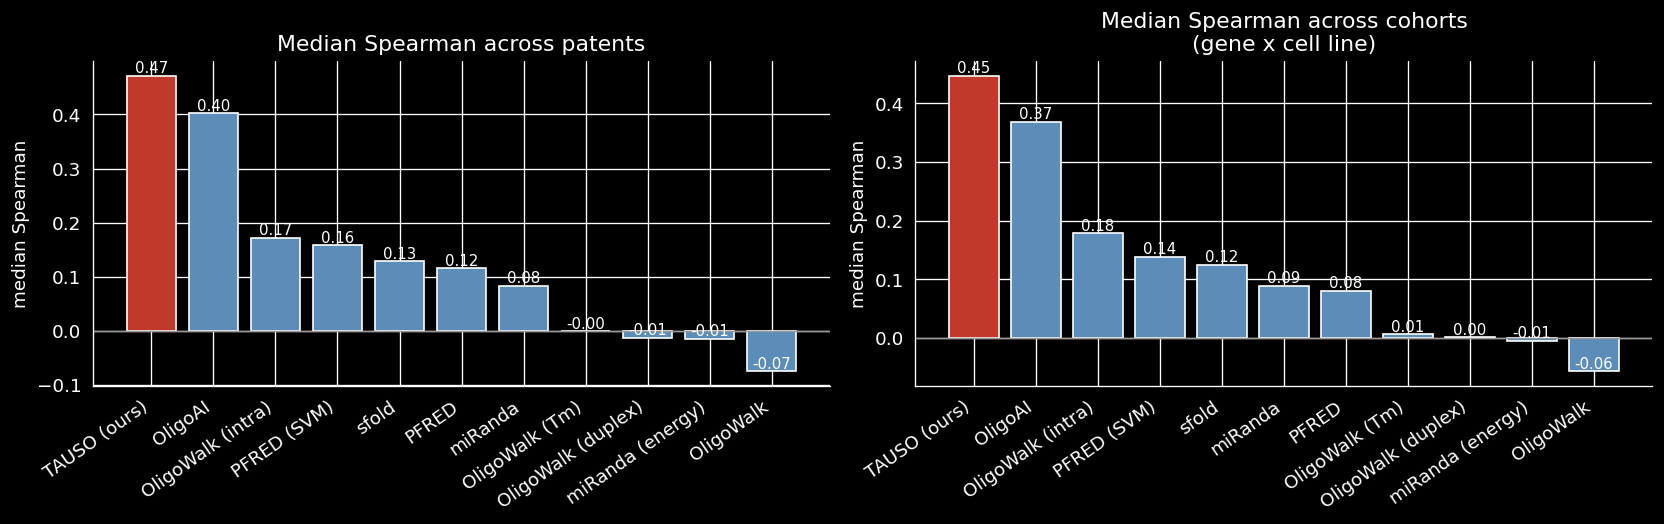

In [4]:
# 1a + 1b: the two requested grouping views, side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
bar("spearman_median", "patent_id",       "Median Spearman across patents",  "median Spearman", ax=axes[0])
bar("spearman_median", "gene x cell_line", "Median Spearman across cohorts\n(gene x cell line)", "median Spearman", ax=axes[1])
plt.tight_layout(); plt.show()

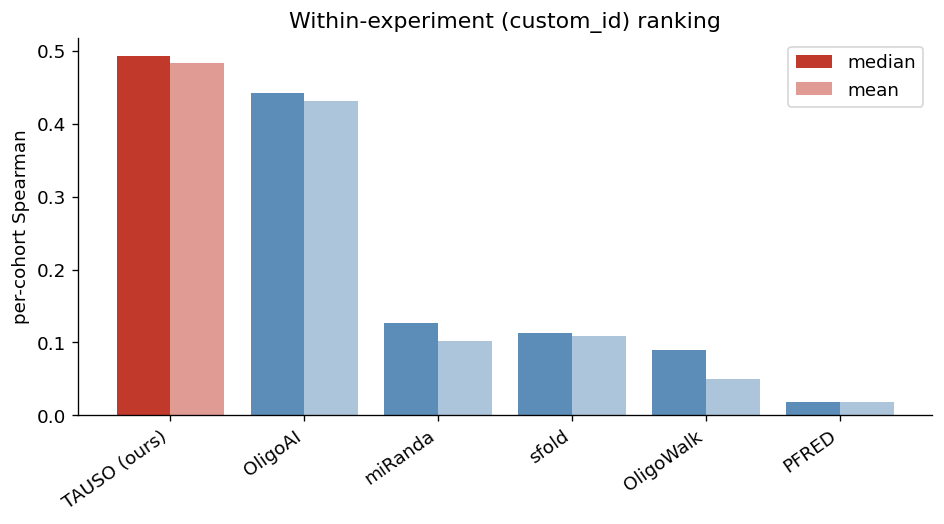

In [5]:
# 1c: mean vs median, custom_id (within-experiment) grouping
fig, ax = plt.subplots(figsize=(8, 4.5))
order = _order(summary[summary.grouping=='custom_id'], 'spearman_median')
order = [s for s in order if s in HEADLINE_SCORERS] or order
d = summary[summary.grouping=='custom_id'].set_index('scorer').reindex(order)
x = np.arange(len(order)); w = 0.4
ax.bar(x-w/2, d['spearman_median'], w, label='median', color=colors(order))
ax.bar(x+w/2, d['spearman_mean'],   w, label='mean',   color=colors(order), alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels([disp(s) for s in order], rotation=35, ha='right')
ax.set_ylabel('per-cohort Spearman'); ax.set_title('Within-experiment (custom_id) ranking'); ax.legend()
plt.tight_layout(); plt.show()

/tmp/claude-1000/ipykernel_3173459/1395561177.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[disp(s) for s in order], showmeans=True, patch_artist=True)


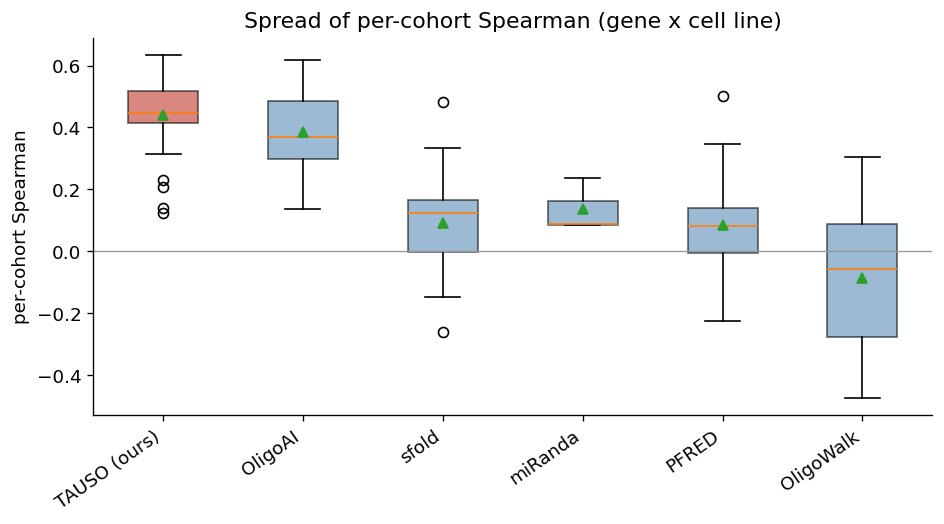

In [6]:
# 1d: distribution of per-cohort Spearman (box), headline scorers, gene x cell_line
g = pergroup[(pergroup.grouping=='gene x cell_line') & (pergroup.scorer.isin(HEADLINE_SCORERS))]
order = [s for s in _order(summary[summary.grouping=='gene x cell_line'],'spearman_median') if s in set(g.scorer)]
data = [g[g.scorer==s].spearman.values for s in order]
fig, ax = plt.subplots(figsize=(8, 4.5))
bp = ax.boxplot(data, labels=[disp(s) for s in order], showmeans=True, patch_artist=True)
for patch, s in zip(bp['boxes'], order): patch.set_facecolor(ACCENT if s==HIGHLIGHT else OTHER); patch.set_alpha(0.6)
ax.axhline(0, color='0.6', lw=0.8); ax.tick_params(axis='x', rotation=35)
for lbl in ax.get_xticklabels(): lbl.set_ha('right')
ax.set_ylabel('per-cohort Spearman'); ax.set_title('Spread of per-cohort Spearman (gene x cell line)')
plt.tight_layout(); plt.show()

## 2. Top-of-ranking quality — Precision@k and top-k potency

For picking a handful of candidates: are the predicted-best oligos actually potent?

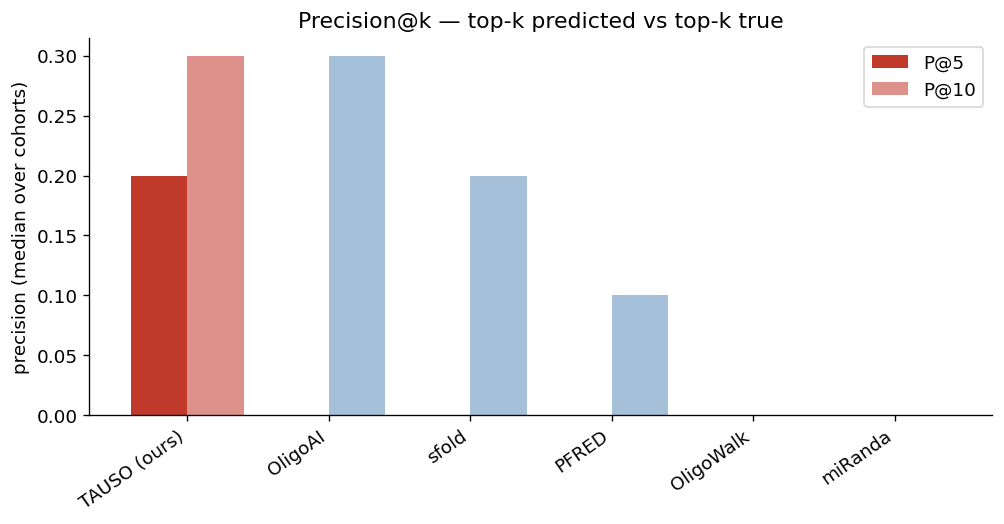

In [7]:
# 2a: Precision@5 and Precision@10 (gene x cell_line)
order = [s for s in _order(summary[summary.grouping=='gene x cell_line'],'p@10_median') if s in HEADLINE_SCORERS] or HEADLINE_SCORERS
d = summary[summary.grouping=='gene x cell_line'].set_index('scorer').reindex(order)
x = np.arange(len(order)); w = 0.4
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(x-w/2, d['p@5_median'],  w, label='P@5',  color=colors(order))
ax.bar(x+w/2, d['p@10_median'], w, label='P@10', color=colors(order), alpha=0.55)
ax.set_xticks(x); ax.set_xticklabels([disp(s) for s in ord  er], rotation=35, ha='right')
ax.set_ylabel('precision (median over cohorts)'); ax.set_title('Precision@k — top-k predicted vs top-k true'); ax.legend()
plt.tight_layout(); plt.show()

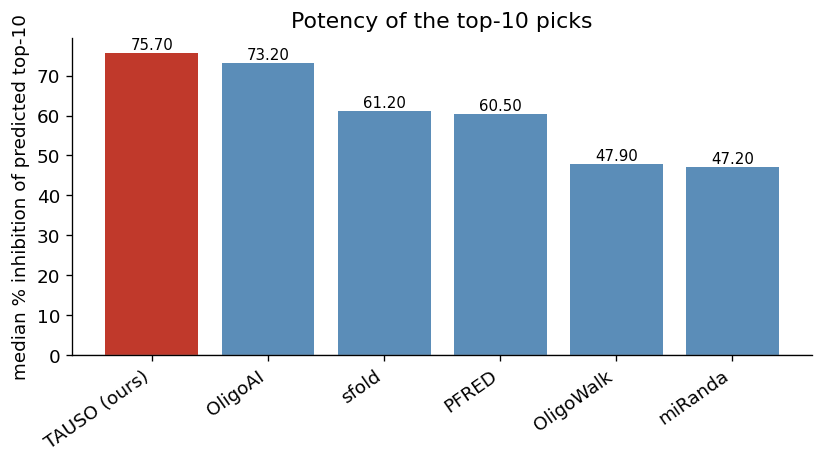

In [8]:
# 2b: mean true inhibition of each scorer's top-10 picks (gene x cell_line)
ax = bar('top10_inhib_median', 'gene x cell_line',
         "Potency of the top-10 picks", "median % inhibition of predicted top-10",
         scorers=[s for s in _order(summary[summary.grouping=='gene x cell_line'],'top10_inhib_median') if s in HEADLINE_SCORERS])
plt.tight_layout(); plt.show()

## 3. Global calibration

Absolute-error regime (across all test rows, no grouping).

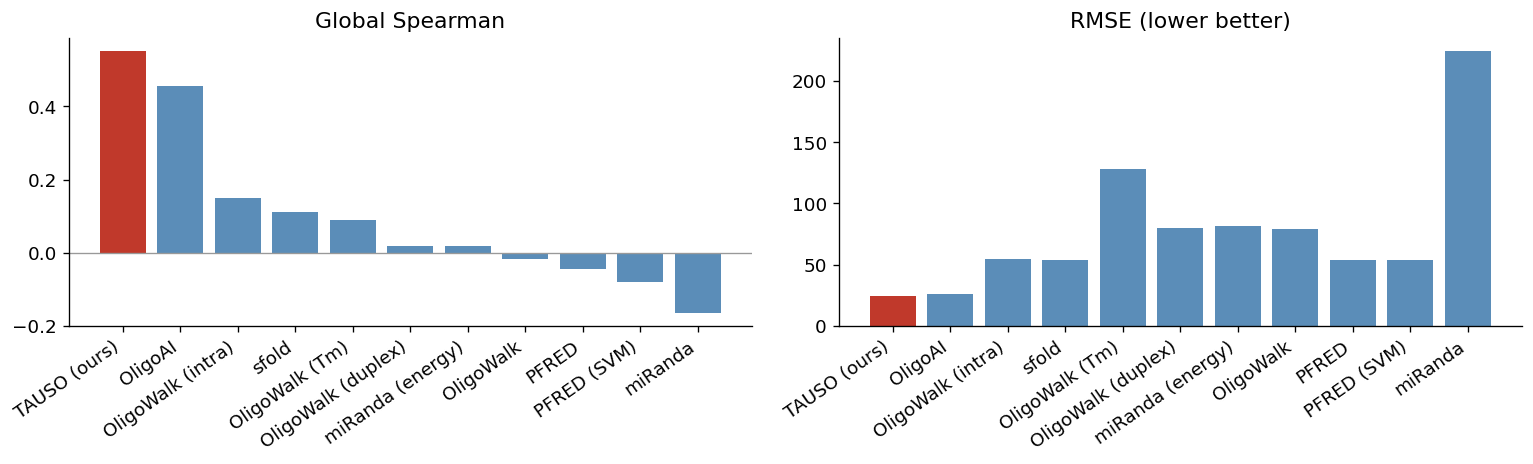

In [9]:
glob = summary[summary.grouping=='GLOBAL'].dropna(subset=['global_spearman']).copy()
glob = glob.set_index('scorer').reindex(_order(glob,'global_spearman'))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
o = [s for s in glob.index]
axes[0].bar([disp(s) for s in o], glob['global_spearman'], color=colors(o)); axes[0].set_title('Global Spearman'); axes[0].axhline(0,color='0.6',lw=0.8)
axes[1].bar([disp(s) for s in o], glob['RMSE'], color=colors(o)); axes[1].set_title('RMSE (lower better)')
for a in axes:
    a.tick_params(axis='x', rotation=35)
    for lbl in a.get_xticklabels(): lbl.set_ha('right')
plt.tight_layout(); plt.show()

## 4. Summary table

In [10]:
cols = ['spearman_median','p@5_median','p@10_median','top10_inhib_median','ndcg10_median']
tbl = (summary[summary.grouping=='gene x cell_line'].set_index('scorer')[cols]
       .reindex(_order(summary[summary.grouping=='gene x cell_line'],'spearman_median')).round(3))
tbl.index = [disp(s) for s in tbl.index]
tbl

,spearman_median,p@5_median,p@10_median,top10_inhib_median,ndcg10_median
TAUSO (ours),0.448,0.2,0.3,75.7,0.848
OligoAI,0.369,0.0,0.3,73.2,0.808
OligoWalk (intra),0.178,0.0,0.1,58.4,0.665
PFRED (SVM),0.138,0.0,0.1,56.2,0.626
sfold,0.125,0.0,0.2,61.2,0.694
miRanda,0.088,0.0,0.0,47.2,0.641
PFRED,0.081,0.0,0.1,60.5,0.711
OligoWalk (Tm),0.006,0.0,0.0,55.8,0.587
OligoWalk (duplex),0.001,0.0,0.0,52.7,0.590
miRanda (energy),-0.005,0.0,0.0,56.4,0.575
